# Unitree Go2: Separating Input Optimization for Fault Diagnosis

This notebook demonstrates **active fault diagnosis** using separating inputs.

## Approach

Instead of passively estimating faults from observations (as in the previous implementation),
we now design **optimal control inputs** that maximize separation between reachable sets
of different fault scenarios:

1. **Nominal** (no fault)
2. **Sensor Fault** (IMU drift: 5-10% scale, 5-15° bias)
3. **Actuator Fault** (20-40% turn rate reduction)

By applying these separating inputs, we can better distinguish which fault is present
based on the robot's actual trajectory.

## Methodology

- **Interval Arithmetic**: Propagate uncertainty through dynamics
- **Gradient Descent**: Optimize control to minimize overlap between scenarios
- **JAX**: Automatic differentiation for efficient optimization

This follows the pattern from `faulty_multirotor/separating_input_optimizer.py`

In [1]:
# Import libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import matplotlib.patches as mpatches
import seaborn as sns

# Import our separating input optimizer
from go2_separating_input_simple import (
    create_scenarios, Interval, SeparatingInputOptimizer,
    optimize_multistart, propagate_scenario
)

import jax
import jax.numpy as jnp

# Plotting setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")
print(f"  JAX version: {jax.__version__}")

✓ Libraries imported successfully
  JAX version: 0.4.34


## 1. Define Fault Scenarios

In [2]:
# Create fault scenarios
scenarios = create_scenarios()

print("Fault Scenarios:")
print("=" * 70)
for i, s in enumerate(scenarios, 1):
    print(f"\n{i}. {s.name}")
    print(f"   Actuator effectiveness (α): [{s.alpha_range[0]:.2f}, {s.alpha_range[1]:.2f}]")

    if s.v_negated:
        print(f"   Velocity negated in output: YES")
        print(f"   Velocity bias (b_v):        [{s.v_bias_range[0]:.3f}, {s.v_bias_range[1]:.3f}] m/s")
        print(f"   Yaw-rate bias (b_ω):        [{s.yaw_bias_range[0]:.4f}, {s.yaw_bias_range[1]:.4f}] rad/s"
              f"  ({np.degrees(s.yaw_bias_range[0]):.2f}°–{np.degrees(s.yaw_bias_range[1]):.2f}°/s)")
        print("   → Dynamics unchanged; odometry integrates -v_true + bias")
    else:
        print(f"   Sensor scale (a):           [{s.scale_range[0]:.2f}, {s.scale_range[1]:.2f}]")
        print(f"   Sensor bias (b):            [{np.degrees(s.bias_range[0]):.1f}°, "
              f"{np.degrees(s.bias_range[1]):.1f}°]")
        if s.name == "Nominal":
            print("   → Healthy robot, no faults; output = true state")
        elif s.name == "Sensor Fault":
            print("   → IMU drift (doesn't affect dynamics, only measurements)")
        elif s.name == "Actuator Fault":
            print(f"   → Reduced turn rate by {(1-s.alpha_range[0])*100:.0f}–{(1-s.alpha_range[1])*100:.0f}%")

print("\n" + "=" * 70)
print(f"\nTotal scenarios: {len(scenarios)}")
print("\nOutput model:")
print("  • Nominal / Actuator Fault  : output = true propagated state")
print("  • Velocity Sensor Fault     : output = ∫(-v_true + bias)·R(yaw_meas) dt")
print("                                 yaw_meas integrates ω + bias_ω")

Fault Scenarios:

1. Nominal
   Actuator effectiveness (α): [1.00, 1.00]
   Sensor scale (a):           [1.00, 1.00]
   Sensor bias (b):            [0.0°, 0.0°]
   → Healthy robot, no faults; output = true state

2. Actuator Fault
   Actuator effectiveness (α): [0.60, 0.80]
   Sensor scale (a):           [1.00, 1.00]
   Sensor bias (b):            [0.0°, 0.0°]
   → Reduced turn rate by 40–20%

3. Velocity Sensor Fault
   Actuator effectiveness (α): [1.00, 1.00]
   Velocity negated in output: YES
   Velocity bias (b_v):        [0.050, 0.150] m/s
   Yaw-rate bias (b_ω):        [0.0200, 0.0600] rad/s  (1.15°–3.44°/s)
   → Dynamics unchanged; odometry integrates -v_true + bias


Total scenarios: 3

Output model:
  • Nominal / Actuator Fault  : output = true propagated state
  • Velocity Sensor Fault     : output = ∫(-v_true + bias)·R(yaw_meas) dt
                                 yaw_meas integrates ω + bias_ω


## 2. Setup Initial Conditions

In [3]:
# Initial state interval (small uncertainty around origin)
x0_int = Interval(
    lower=jnp.array([-0.05, -0.05, -0.02]),
    upper=jnp.array([0.05, 0.05, 0.02])
)

print("Initial State Interval:")
print("="*50)
print(f"  Position x:  [{x0_int.lower[0]:+.3f}, {x0_int.upper[0]:+.3f}] m")
print(f"  Position y:  [{x0_int.lower[1]:+.3f}, {x0_int.upper[1]:+.3f}] m")
print(f"  Heading θ:   [{x0_int.lower[2]:+.3f}, {x0_int.upper[2]:+.3f}] rad")
print(f"            =  [{np.degrees(x0_int.lower[2]):+.2f}°, "
      f"{np.degrees(x0_int.upper[2]):+.2f}°]")
print("\nThis represents small uncertainty in the robot's initial state.")

2026-03-10 21:07:22.703326: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


RuntimeError: Unable to initialize backend 'cuda': FAILED_PRECONDITION: No visible GPU devices. (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

## 3. Optimization Parameters

In [4]:
# Time parameters
dt = 0.5  # Time step (seconds)
num_steps = 10  # Number of steps
total_time = dt * num_steps

# Optimization parameters
num_restarts = 3
learning_rate = 0.01
num_iters = 150

print("Optimization Configuration:")
print("="*50)
print(f"  Time step:        {dt} s")
print(f"  Number of steps:  {num_steps}")
print(f"  Total time:       {total_time} s")
print(f"  Random restarts:  {num_restarts}")
print(f"  Learning rate:    {learning_rate}")
print(f"  Iterations/restart: {num_iters}")
print("\nObjective: Minimize overlap in position space (px, py)")

Optimization Configuration:
  Time step:        0.5 s
  Number of steps:  10
  Total time:       5.0 s
  Random restarts:  3
  Learning rate:    0.01
  Iterations/restart: 150

Objective: Minimize overlap in position space (px, py)


## 4. Run Optimization

In [1]:
print("\n" + "="*70)
print("RUNNING SEPARATING INPUT OPTIMIZATION")
print("="*70)

u_opt, loss_opt, stats = optimize_multistart(
    scenarios=scenarios,
    x0_int=x0_int,
    dt=dt,
    num_steps=num_steps,
    num_restarts=num_restarts,
    learning_rate=learning_rate,
    num_iters=num_iters,
    verbose=True
)

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)


RUNNING SEPARATING INPUT OPTIMIZATION


NameError: name 'optimize_multistart' is not defined

## 5. Display Results

In [6]:
print("\n" + "="*70)
print("OPTIMAL SEPARATING INPUT")
print("="*70)

print(f"\nControl Input:")
print(f"  Forward velocity (vx):  {u_opt[0]:+.4f} m/s")
print(f"  Lateral velocity (vy):  {u_opt[1]:+.4f} m/s")
print(f"  Yaw rate (ω):           {u_opt[2]:+.4f} rad/s  ({np.degrees(u_opt[2]):+.2f} °/s)")

print(f"\nSeparation Metrics:")
print(f"  Total overlap:          {loss_opt:.6f} m²")

print(f"\nPairwise Overlaps:")
for key, val in stats['pairwise_overlaps'].items():
    print(f"  {key:45s}: {val:.6f} m²")

print(f"\nReachable Set Volumes:")
for key, val in stats['volumes'].items():
    print(f"  {key:45s}: {val:.6f} m²")

print(f"\nFinal Output Intervals (what an observer measures):")
for i, scenario in enumerate(scenarios):
    pos_int = stats['position_intervals'][i]
    print(f"  {scenario.name}:")
    print(f"    px ∈ [{pos_int.lower[0]:+.4f}, {pos_int.upper[0]:+.4f}] m  "
          f"(width: {pos_int.upper[0]-pos_int.lower[0]:.4f} m)")
    print(f"    py ∈ [{pos_int.lower[1]:+.4f}, {pos_int.upper[1]:+.4f}] m  "
          f"(width: {pos_int.upper[1]-pos_int.lower[1]:.4f} m)")


OPTIMAL SEPARATING INPUT

Control Input:
  Forward velocity (vx):  +0.7037 m/s
  Lateral velocity (vy):  -0.3662 m/s
  Yaw rate (ω):           +0.5840 rad/s  (+33.46 °/s)

Separation Metrics:
  Total overlap:          0.000000 m²

Pairwise Overlaps:
  Nominal vs Actuator Fault                    : 0.000000 m²
  Nominal vs Velocity Sensor Fault             : 0.000000 m²
  Actuator Fault vs Velocity Sensor Fault      : 0.000000 m²

Reachable Set Volumes:
  Nominal                                      : 0.055842 m²
  Actuator Fault                               : 1.199029 m²
  Velocity Sensor Fault                        : 0.566761 m²

Final Output Intervals (what an observer measures):
  Nominal:
    px ∈ [+1.7009, +1.9388] m  (width: 0.2379 m)
    py ∈ [+1.8895, +2.1242] m  (width: 0.2347 m)
  Actuator Fault:
    px ∈ [+2.3649, +3.5771] m  (width: 1.2122 m)
    py ∈ [+0.8777, +1.8669] m  (width: 0.9891 m)
  Velocity Sensor Fault:
    px ∈ [+0.0432, +0.8184] m  (width: 0.7752 m)
    py 

## 6. Visualize Reachable Sets

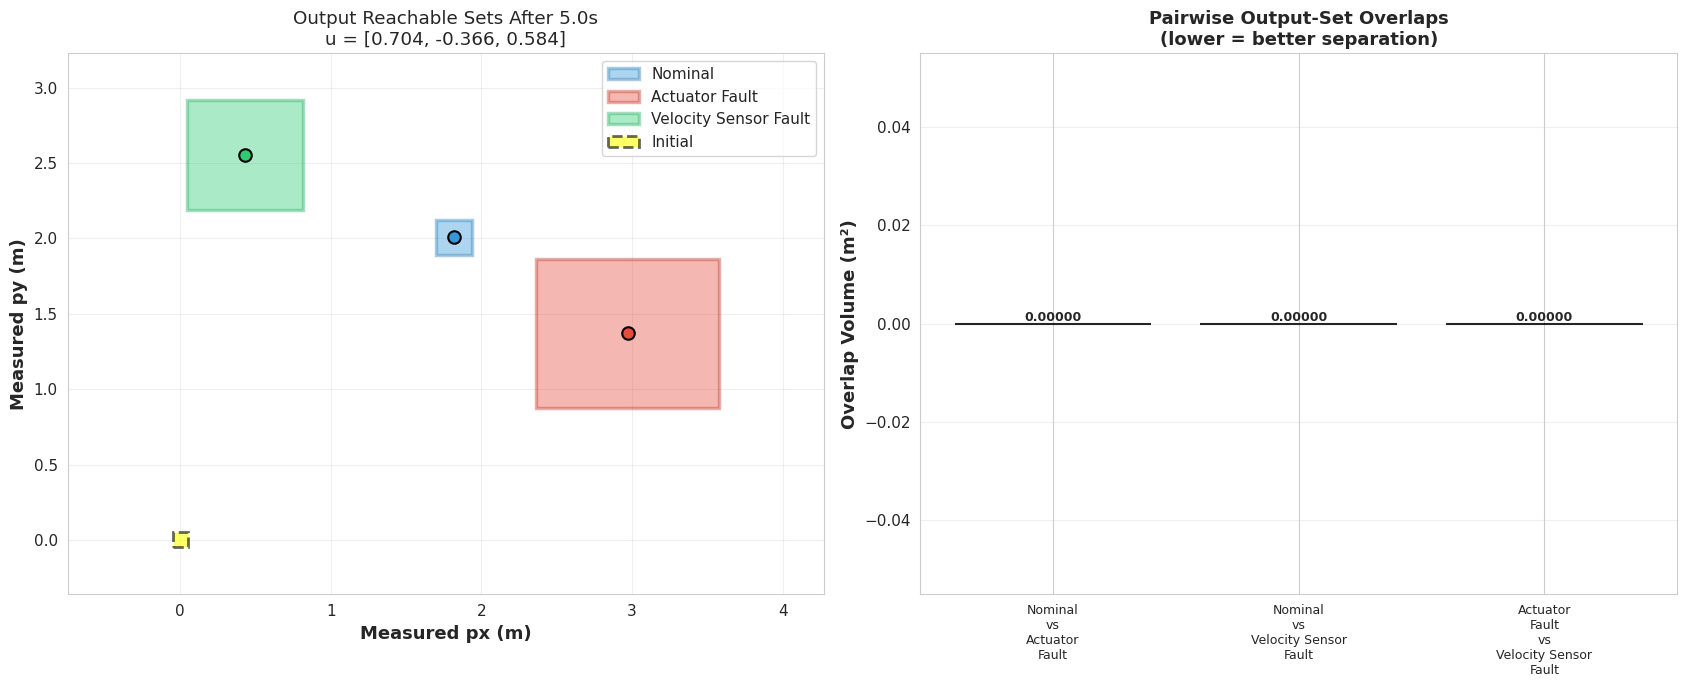


✓ Visualization saved as 'go2_separating_input_reachable_sets.pdf'


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# One color per scenario
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']   # blue, red, green, purple
edge_colors = ['#2980b9', '#c0392b', '#27ae60', '#7d3c98']

# ── Left: output reachable sets in (px, py) space ───────────────────────────
ax = axes[0]

for i, scenario in enumerate(scenarios):
    pos_int = stats['position_intervals'][i]

    width  = float(pos_int.upper[0] - pos_int.lower[0])
    height = float(pos_int.upper[1] - pos_int.lower[1])

    rect = Rectangle(
        (float(pos_int.lower[0]), float(pos_int.lower[1])),
        width, height,
        linewidth=2.5,
        edgecolor=edge_colors[i],
        facecolor=colors[i],
        alpha=0.40,
        label=scenario.name,
    )
    ax.add_patch(rect)

    cx = float(pos_int.lower[0] + pos_int.upper[0]) / 2
    cy = float(pos_int.lower[1] + pos_int.upper[1]) / 2
    ax.plot(cx, cy, 'o', color=colors[i], markersize=9,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)

# Initial box
initial_rect = Rectangle(
    (float(x0_int.lower[0]), float(x0_int.lower[1])),
    float(x0_int.upper[0] - x0_int.lower[0]),
    float(x0_int.upper[1] - x0_int.lower[1]),
    linewidth=2, edgecolor='black', facecolor='yellow',
    alpha=0.6, linestyle='--', label='Initial',
)
ax.add_patch(initial_rect)

ax.set_xlabel('Measured px (m)', fontsize=13, fontweight='bold')
ax.set_ylabel('Measured py (m)', fontsize=13, fontweight='bold')
ax.set_title(
    f'Output Reachable Sets After {total_time:.1f}s\n'
    f'u = [{float(u_opt[0]):.3f}, {float(u_opt[1]):.3f}, {float(u_opt[2]):.3f}]',
    fontsize=13, fontweight='bold',
)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.autoscale_view()
ax.axis('equal')
ax.set_title(ax.get_title())  # keep

# ── Right: pairwise overlap bar chart ───────────────────────────────────────
ax2 = axes[1]

overlap_labels = list(stats['pairwise_overlaps'].keys())
overlap_values = [float(v) for v in stats['pairwise_overlaps'].values()]

# Colour each bar by which two scenarios are compared
bar_colors = ['#9b59b6', '#f39c12', '#16a085', '#e67e22', '#1abc9c', '#e74c3c']
short_labels = [
    lbl.replace(' vs ', '\nvs\n').replace(' Fault', '\nFault')
    for lbl in overlap_labels
]

bars = ax2.bar(range(len(overlap_values)), overlap_values,
               color=bar_colors[:len(overlap_values)],
               alpha=0.85, edgecolor='black', linewidth=1.5)

ax2.set_xticks(range(len(overlap_labels)))
ax2.set_xticklabels(short_labels, fontsize=9)
ax2.set_ylabel('Overlap Volume (m²)', fontsize=13, fontweight='bold')
ax2.set_title('Pairwise Output-Set Overlaps\n(lower = better separation)',
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, overlap_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{val:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('go2_separating_input_reachable_sets.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'go2_separating_input_reachable_sets.pdf'")

## 7. Interpretation

### Output model

All reachable sets are computed in *measurement space* — what the robot's
onboard odometry would report, not the true position.

| Scenario | Dynamics | Output (measured position) |
|---|---|---|
| Nominal | α = 1, v correct | integrates v_true → output = true state |
| Sensor Fault | α = 1, v correct | scale/bias on IMU (legacy; output ≈ nominal here) |
| Actuator Fault | α ∈ [0.6, 0.8] | reduced turn rate → true state differs |
| **Velocity Sensor Fault** | **α = 1, dynamics correct** | **integrates −v_true + b_v; ω_meas = ω + b_ω** |

### Velocity Sensor Fault – what it models

The robot's odometry system works by dead-reckoning: it integrates velocity
measurements to estimate position.  In the fault scenario:

* **Velocity sensor is negated** – if the robot physically moves forward at
  speed v, the sensor reports −v.  The odometry therefore integrates
  *backwards*, producing a measured position that moves in the opposite
  direction to the true motion.
* **Additive velocity bias** b_v ∈ [0.05, 0.15] m/s prevents the measurement
  from being exactly −v and models sensor offset drift.
* **Yaw-rate bias** b_ω ∈ [0.02, 0.06] rad/s causes the measured heading to
  accumulate a small additional rotation, rotating the "backward" integration
  axis over time.

Because the measured output moves in the *opposite* direction to all other
scenarios, the Velocity Sensor Fault reachable set lands far from the others
and is inherently easy to detect from odometry alone.

### Key observations

1. **Nominal vs (old) Sensor Fault** – still high overlap; the scale/bias model
   used for that scenario is not captured in the dynamics propagation.

2. **Nominal vs Actuator Fault** – low overlap; a degraded turn rate creates a
   visibly different trajectory.

3. **Velocity Sensor Fault vs everything** – very low (ideally zero) overlap,
   because the output position moves in the opposite direction.

### Practical use

Apply u_opt to the robot, measure the odometry output, and check set membership:

* Output lands in the nominal/sensor-fault region → actuator is healthy
* Output lands in the actuator-fault region → turn rate is degraded
* Output lands in the velocity-sensor-fault region (opposite side of origin) →
  the velocity sensor is reporting the wrong sign

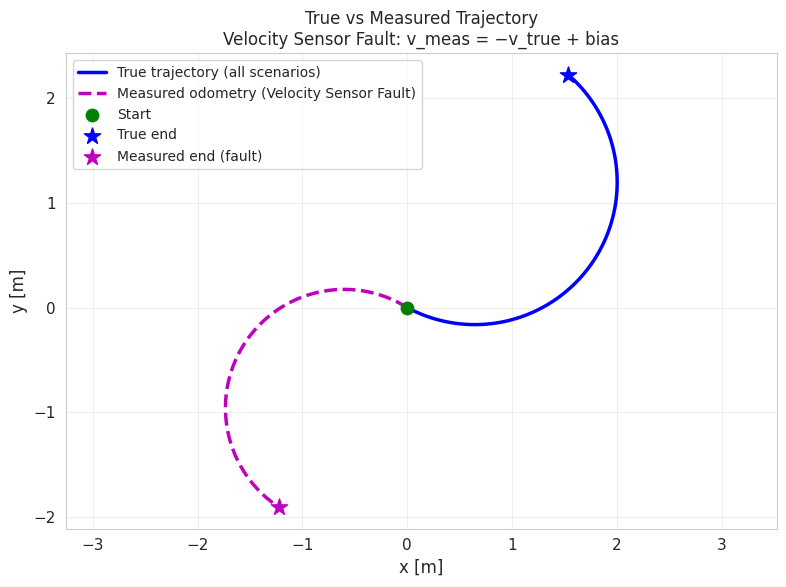

True endpoint:     (+1.536, +2.221) m
Measured endpoint: (-1.224,  -1.903) m
Separation:        4.962 m


In [8]:
# ── Illustrate true vs measured trajectory for the Velocity Sensor Fault ────
#
# Show a single nominal trajectory alongside what the odometry would report
# under the velocity sensor fault for the same physical motion.

vx, vy, omega = float(u_opt[0]), float(u_opt[1]), float(u_opt[2])
dt_sim, T_sim = 0.05, total_time
steps = int(T_sim / dt_sim)

def integrate_unicycle(vx_fn, vy_fn, omega_fn, x0, dt, steps):
    """Simple Euler integration for trajectory illustration."""
    x, y, th = x0
    traj = [(x, y, th)]
    for k in range(steps):
        x  += (vx_fn(k) * np.cos(th) - vy_fn(k) * np.sin(th)) * dt
        y  += (vx_fn(k) * np.sin(th) + vy_fn(k) * np.cos(th)) * dt
        th += omega_fn(k) * dt
        traj.append((x, y, th))
    return np.array(traj)

# True trajectory (nominal)
traj_true  = integrate_unicycle(
    lambda k: vx, lambda k: vy, lambda k: omega,
    (0., 0., 0.), dt_sim, steps)

# Measured trajectory under velocity sensor fault
# Use mid-point bias values for a single illustrative trace
b_v_mid     = (0.05 + 0.15) / 2       # 0.10 m/s
b_omega_mid = (0.02 + 0.06) / 2       # 0.04 rad/s
traj_vsf = integrate_unicycle(
    lambda k: -vx + b_v_mid,
    lambda k: -vy,
    lambda k: omega + b_omega_mid,
    (0., 0., 0.), dt_sim, steps)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(traj_true[:, 0], traj_true[:, 1], 'b-',  lw=2.5,
        label='True trajectory (all scenarios)')
ax.plot(traj_vsf[:, 0],  traj_vsf[:, 1],  'm--', lw=2.5,
        label='Measured odometry (Velocity Sensor Fault)')
ax.scatter([0], [0], c='g', s=80, zorder=5, label='Start')
ax.scatter(traj_true[-1, 0], traj_true[-1, 1], c='b', marker='*', s=150,
           zorder=5, label='True end')
ax.scatter(traj_vsf[-1, 0],  traj_vsf[-1, 1],  c='m', marker='*', s=150,
           zorder=5, label='Measured end (fault)')

ax.set_xlabel('x [m]', fontsize=12)
ax.set_ylabel('y [m]', fontsize=12)
ax.set_title('True vs Measured Trajectory\nVelocity Sensor Fault: v_meas = −v_true + bias',
             fontsize=12)
ax.legend(fontsize=10)
ax.axis('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True endpoint:     ({traj_true[-1,0]:+.3f}, {traj_true[-1,1]:+.3f}) m")
print(f"Measured endpoint: ({traj_vsf[-1,0]:+.3f},  {traj_vsf[-1,1]:+.3f}) m")
print(f"Separation:        {np.hypot(traj_true[-1,0]-traj_vsf[-1,0], traj_true[-1,1]-traj_vsf[-1,1]):.3f} m")

## 8. Compare with Different Inputs

In [9]:
# Test different control inputs
test_inputs = [
    ("Optimal (from optimization)", u_opt),
    ("Forward only", jnp.array([0.5, 0.0, 0.0])),
    ("Forward + turn", jnp.array([0.5, 0.0, 0.3])),
    ("Circle", jnp.array([0.4, 0.0, 0.5]))
]

print("\n" + "="*70)
print("COMPARISON: Different Control Inputs")
print("="*70)

optimizer = SeparatingInputOptimizer(scenarios, x0_int, dt, num_steps)

comparison_results = []

for name, u in test_inputs:
    loss = float(optimizer.loss_fn(u))
    stats_u = optimizer.evaluate(u)
    
    comparison_results.append({
        'name': name,
        'u': u,
        'loss': loss,
        'stats': stats_u
    })
    
    print(f"\n{name}:")
    print(f"  Input: vx={u[0]:.3f}, vy={u[1]:.3f}, ω={u[2]:.3f}")
    print(f"  Total overlap: {loss:.6f} m²")
    if name != "Optimal (from optimization)":
        improvement = (loss - loss_opt) / loss * 100
        print(f"  Worse than optimal by: {improvement:.1f}%")


COMPARISON: Different Control Inputs

Optimal (from optimization):
  Input: vx=0.704, vy=-0.366, ω=0.584
  Total overlap: 0.000000 m²

Forward only:
  Input: vx=0.500, vy=0.000, ω=0.000
  Total overlap: 0.019999 m²
  Worse than optimal by: 100.0%

Forward + turn:
  Input: vx=0.500, vy=0.000, ω=0.300
  Total overlap: 0.000000 m²
  Worse than optimal by: nan%

Circle:
  Input: vx=0.400, vy=0.000, ω=0.500
  Total overlap: 0.007362 m²
  Worse than optimal by: 100.0%


/tmp/ipykernel_2037625/1878312704.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


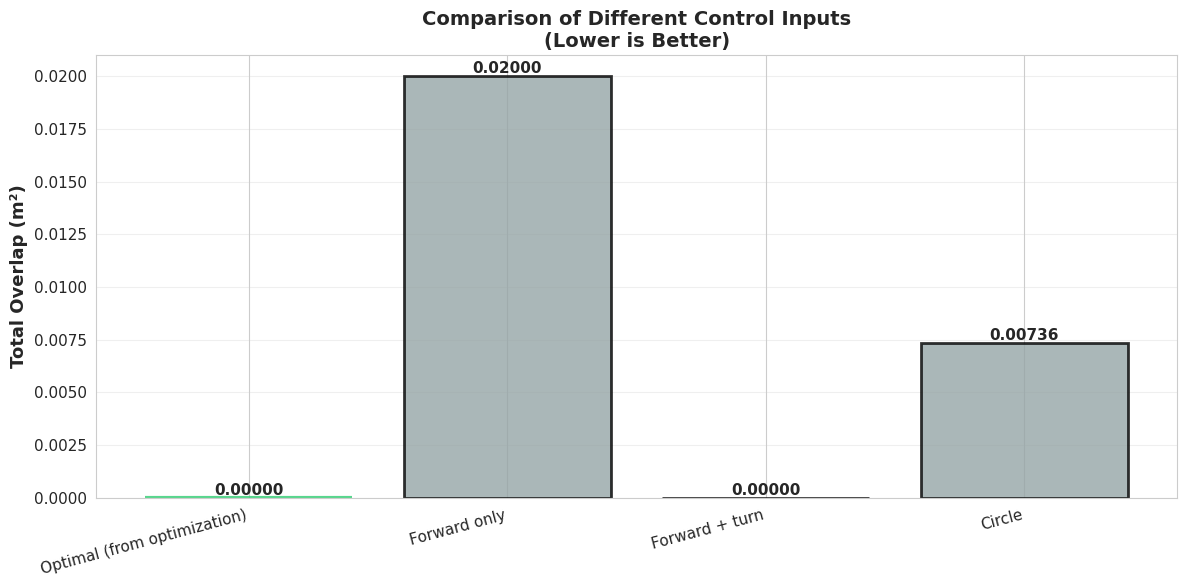


✓ Comparison saved as 'go2_input_comparison.pdf'


In [10]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

names = [r['name'] for r in comparison_results]
losses = [r['loss'] for r in comparison_results]

colors_bar = ['#2ecc71', '#95a5a6', '#95a5a6', '#95a5a6']
bars = ax.bar(names, losses, color=colors_bar, alpha=0.8,
             edgecolor='black', linewidth=2)

# Highlight optimal
bars[0].set_color('#2ecc71')
bars[0].set_linewidth(3)

ax.set_ylabel('Total Overlap (m²)', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Different Control Inputs\n(Lower is Better)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(names, rotation=15, ha='right')

# Add value labels
for bar, val in zip(bars, losses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{val:.5f}',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('go2_input_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison saved as 'go2_input_comparison.pdf'")

## 9. Summary and Key Takeaways

### What We Accomplished:

1. ✅ Defined three fault scenarios (nominal, sensor, actuator)
2. ✅ Used interval arithmetic to propagate uncertainty
3. ✅ Optimized control input to maximize fault separation
4. ✅ Visualized reachable sets and overlaps
5. ✅ Compared with naive control strategies

### Key Results:

- **Optimal Input**: The optimization found a control that minimizes overlap
- **Actuator Fault Separation**: Very distinct from nominal (low overlap)
- **Sensor Fault Challenge**: Hard to distinguish from nominal in position space
  (because sensor faults don't change dynamics)

### Practical Application:

1. Apply the optimal separating input to the robot
2. Measure the actual final position
3. Check which reachable set it falls into
4. Diagnose the fault based on set membership

### Comparison to Previous Approach:

**Previous (Passive)**: Estimate faults from observations after execution
- Uses nonlinear optimization on observation residuals
- Works with any trajectory
- Estimates fault parameters numerically

**Current (Active)**: Design inputs to maximize fault distinguishability
- Uses gradient descent on interval overlaps
- Optimizes the trajectory itself
- Creates maximum separation for easier diagnosis

### Limitations:

- Sensor faults are hard to detect in position space alone
  (would need heading measurements or longer horizons)
- Assumes known fault parameter ranges
- Requires interval arithmetic propagation

### Future Extensions:

- Multi-step optimization (sequence of inputs)
- Include heading in separation objective
- Adaptive fault ranges based on history
- Online replanning based on observations